<a href="https://colab.research.google.com/github/Bonkerzz2603/TH_deaplearn/blob/main/NguyenGiaKhang_THDeepLearn_tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## RNN (CONVOLUTIONAL NEURAL NETWORK)

In [8]:
import pandas as pd
from pandas import read_csv
import numpy as np
import tensorflow as tf
from keras.layers import  Dense, SimpleRNN
from keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

#Ham Dinh Nghia


In [5]:
#hidden units: 2blocks
#dense_units : 1blocks
#input_shape: (time steps + features)
#activation: linear f(x) = x
def create_RNN(hidden_units, dense_units, input_shape, activation):
  model = Sequential()
  model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
  model.add(Dense(dense_units, activation=activation[1]))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

demo_RNN =(2,1,(3,1),['linear','linear'])

#Các tham số sinh bởi RNN

In [11]:
rnn_model = create_RNN(demo_RNN[0], demo_RNN[1], demo_RNN[2], demo_RNN[3])

wx = rnn_model.get_weights()[0]
wh = rnn_model.get_weights()[1]
bh = rnn_model.get_weights()[2]
wy = rnn_model.get_weights()[3]
by = rnn_model.get_weights()[4]

print('wx= ', wx)
print('wh= ', wh)
print('bh= ', bh)
print('wy= ', wy)
print('by= ', by)

wx=  [[1.2787536 0.3797387]]
wh=  [[ 0.9597628   0.28081185]
 [ 0.28081185 -0.9597628 ]]
bh=  [0. 0.]
wy=  [[-1.3323121]
 [ 0.8725153]]
by=  [0.]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#Tính vector hidden cho tầng recurrent

In [14]:
x = np.array([1,2,3])
x_input = np.reshape(x,(1,3,1))
y_predict_model = rnn_model.predict(x_input)

m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + bh + h0
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh
o3 = np.dot(h3, wy) + by

print('h1= ', h1)
print('h2= ', h2)
print('h3= ', h3)

print('Prediction of model')
print('Prediction from computation: ', o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
h1=  [[1.27875364 0.37973869]]
h2=  [[3.89144259 0.75410748]]
h3=  [[7.78288511 1.50821493]]
Prediction of model
Prediction from computation:  [[-9.05329142]]


data: https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv



In [18]:

def get_train_test(url, split_precent=0.8):
  df = pd.read_csv(url, usecols=[1], engine='python')
  data = np.array(df.values.astype('float32'))
  scaler = MinMaxScaler(feature_range=(0,1))
  data = scaler.fit_transform(data).flatten()

  n = len(data)

  split = int(n * split_precent)
  train_data = data[range(split)]
  test_data = data[split:]
  return train_data, test_data, data

sunspot_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspot_url)


In [21]:
def get_XY(dat, time_steps):
  y_ind = np.arange(time_steps, len(dat), time_steps)
  Y = dat[y_ind]
  rows_x = len(Y)
  X = dat[range(time_steps * rows_x)]
  X = np.reshape(X, (rows_x, time_steps, 1))
  return X, Y

time_steps = 12
X_train, Y_train = get_XY(train_data, time_steps)
X_test, Y_test = get_XY(test_data, time_steps)

#Taoj RNN Model va Huan Luyen

In [24]:
model = create_RNN(2, 1, (time_steps, 1), ['linear', 'linear'])
model.fit(X_train, Y_train, epochs=20, verbose=1)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.6585
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0701
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6596
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4304
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2818
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1931
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1478
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1244
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1098
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1008
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0934
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0870
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0810
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0750
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0694
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━

# ham tinh hieu qua model

In [26]:

def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))

    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

# make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Mean square error
print_error(Y_train, Y_test, train_predict, test_predict)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Train RMSE: 0.212 RMSE
Test RMSE: 0.322 RMSE


#danh gia ket qua

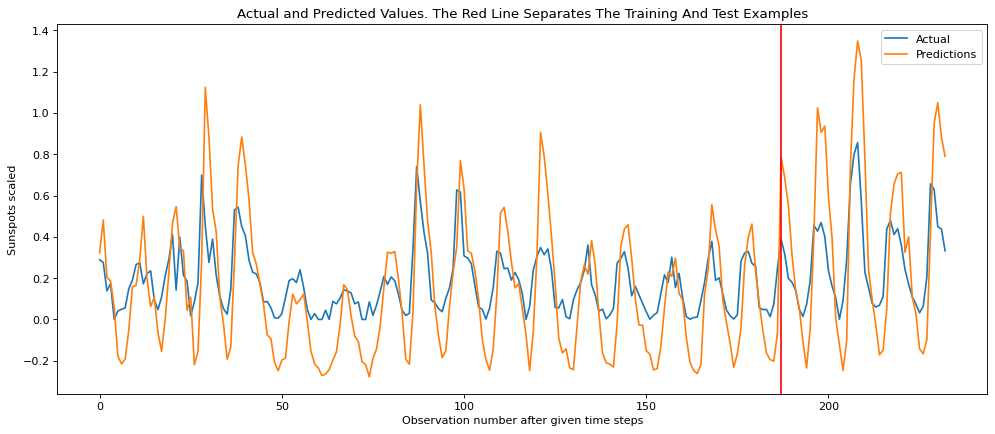

In [29]:
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

plot_result(Y_train, Y_test, train_predict, test_predict)